# TCGA-PAAD Clinical Data Cleaning & EDA
**Author:** Simran Randhawa  
**Data:** TCGA-PAAD clinical files downloaded from NCI GDC  

## Overview
This notebook loads and merges three raw TCGA clinical data files, handles 
missing values, standardizes coded variables, and produces a clean dataset 
for downstream survival analysis in R.

**Files used:**
- `clinical.tsv` — primary patient demographics and diagnosis info
- `follow_up.tsv` — updated survival status and follow-up time
- `exposure.tsv` — smoking and alcohol history

**Key cleaning steps:**
1. Load and inspect all three files
2. Identify and handle missing values
3. Merge tables on patient ID
4. Standardize survival time and vital status variables
5. Export clean dataset for R

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

print("Libraries loaded successfully")
print(f"pandas version: {pd.__version__}")

Matplotlib is building the font cache; this may take a moment.


Libraries loaded successfully
pandas version: 3.0.2


## Step 1: Load the Raw Data
Loading all three clinical files and inspecting their shape and columns.

In [2]:
# Define file paths
data_dir = "/Users/simrankrandhawa/local_R_projects/TCGA-PAAD/clinical/"

# Load all three files
clinical = pd.read_csv(data_dir + "clinical.tsv", sep="\t", low_memory=False)
follow_up = pd.read_csv(data_dir + "follow_up.tsv", sep="\t", low_memory=False)
exposure = pd.read_csv(data_dir + "exposure.tsv", sep="\t", low_memory=False)

# Inspect shapes
print("clinical.tsv:  ", clinical.shape)
print("follow_up.tsv: ", follow_up.shape)
print("exposure.tsv:  ", exposure.shape)

clinical.tsv:   (1082, 201)
follow_up.tsv:  (687, 152)
exposure.tsv:   (290, 35)


## Step 2: Inspect & Filter Clinical Data
The raw clinical.tsv contains data across multiple TCGA projects and 
includes duplicate header rows. We filter to PAAD patients only and 
remove junk rows.

In [3]:
# Preview the first few rows
print("First 3 rows of clinical data:")
clinical.head(3)

First 3 rows of clinical data:


,project.project_id,cases.case_id,cases.consent_type,cases.days_to_consent,cases.days_to_lost_to_followup,cases.disease_type,cases.index_date,cases.lost_to_followup,cases.primary_site,cases.submitter_id,demographic.age_at_index,demographic.age_is_obfuscated,demographic.cause_of_death,demographic.cause_of_death_source,demographic.country_of_birth,demographic.country_of_residence_at_enrollment,demographic.days_to_birth,demographic.days_to_death,demographic.demographic_id,demographic.education_level,demographic.ethnicity,demographic.gender,demographic.marital_status,demographic.occupation_duration_years,demographic.population_group,...,treatments.reason_treatment_ended,treatments.reason_treatment_not_given,treatments.regimen_or_line_of_therapy,treatments.residual_disease,treatments.route_of_administration,treatments.submitter_id,treatments.therapeutic_agents,treatments.therapeutic_level_achieved,treatments.therapeutic_levels_achieved,treatments.therapeutic_target_level,treatments.timepoint_category,treatments.treatment_anatomic_sites,treatments.treatment_dose,treatments.treatment_dose_max,treatments.treatment_dose_units,treatments.treatment_duration,treatments.treatment_effect,treatments.treatment_effect_indicator,treatments.treatment_frequency,treatments.treatment_id,treatments.treatment_intent_type,treatments.treatment_or_therapy,treatments.treatment_outcome,treatments.treatment_outcome_duration,treatments.treatment_type
0,TCGA-PAAD,01775b06-5836-469c-8537-120cb8cc94e9,Informed Consent,0,'--,Ductal and Lobular Neoplasms,Diagnosis,No,Pancreas,TCGA-IB-7897,53,False,Cancer Related,Death Certificate,'--,Canada,-19718,486,31f43ced-83c3-5949-9d68-7306832ccc7b,'--,not hispanic or latino,female,'--,'--,'--,...,'--,'--,'--,'--,'--,TCGA-IB-7897_treatment2,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,11f8ab35-d43b-4a86-adaf-31a177ed4863,Adjuvant,no,'--,'--,"Radiation Therapy, NOS"
1,TCGA-PAAD,01775b06-5836-469c-8537-120cb8cc94e9,Informed Consent,0,'--,Ductal and Lobular Neoplasms,Diagnosis,No,Pancreas,TCGA-IB-7897,53,False,Cancer Related,Death Certificate,'--,Canada,-19718,486,31f43ced-83c3-5949-9d68-7306832ccc7b,'--,not hispanic or latino,female,'--,'--,'--,...,'--,'--,'--,'--,'--,TCGA-IB-7897_treatment,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,747e7279-7271-5c39-a57a-5df3bc6145d4,Adjuvant,no,'--,'--,"Pharmaceutical Therapy, NOS"
2,TCGA-PAAD,01775b06-5836-469c-8537-120cb8cc94e9,Informed Consent,0,'--,Ductal and Lobular Neoplasms,Diagnosis,No,Pancreas,TCGA-IB-7897,53,False,Cancer Related,Death Certificate,'--,Canada,-19718,486,31f43ced-83c3-5949-9d68-7306832ccc7b,'--,not hispanic or latino,female,'--,'--,'--,...,'--,'--,'--,'--,'--,TCGA-IB-7897_treatment3,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,e24e0cfd-21f6-4b4d-8c08-806806910dc9,'--,yes,'--,'--,Whipple


In [4]:
# Check how TCGA codes missing values
print("Unique missing-value codes in dataset:")
print(clinical.isin(["'--", "--", "Not Reported", "Unknown"]).sum().sum(), 
      "cells contain placeholder missing values")

# Check for duplicate case IDs
print(f"\nTotal rows: {len(clinical)}")
print(f"Unique patients: {clinical['cases.case_id'].nunique()}")
print(f"Duplicate rows: {len(clinical) - clinical['cases.case_id'].nunique()}")

Unique missing-value codes in dataset:
166772 cells contain placeholder missing values

Total rows: 1082
Unique patients: 185
Duplicate rows: 897


In [5]:
# ── Step 1: Deduplicate — keep one row per patient ────────────
clinical_dedup = clinical.drop_duplicates(subset='cases.case_id', keep='first')
print(f"After deduplication: {len(clinical_dedup)} patients")

# ── Step 2: Replace TCGA placeholder missing values with NaN ──
clinical_clean = clinical_dedup.replace(["'--", "--", "Not Reported", "Unknown"], pd.NA)

# ── Step 3: Select only the columns we need for survival analysis
cols_needed = [
    'cases.case_id',
    'cases.demographic.gender',
    'cases.demographic.race',
    'cases.demographic.age_at_index',
    'cases.demographic.vital_status',
    'cases.demographic.days_to_death',
    'cases.diagnoses.ajcc_pathologic_stage',
    'cases.diagnoses.age_at_diagnosis',
    'cases.diagnoses.days_to_last_follow_up',
    'cases.diagnoses.primary_diagnosis',
    'cases.diagnoses.morphology'
]

# Keep only columns that exist in the file
cols_present = [c for c in cols_needed if c in clinical_clean.columns]
clinical_clean = clinical_clean[cols_present]

print(f"Columns selected: {len(cols_present)}")
print(f"\nMissing values per column:")
print(clinical_clean.isna().sum())

After deduplication: 185 patients
Columns selected: 1

Missing values per column:
cases.case_id    0
dtype: int64


In [6]:
# Print all column names to find the correct ones
for col in clinical_dedup.columns:
    print(col)

project.project_id
cases.case_id
cases.consent_type
cases.days_to_consent
cases.days_to_lost_to_followup
cases.disease_type
cases.index_date
cases.lost_to_followup
cases.primary_site
cases.submitter_id
demographic.age_at_index
demographic.age_is_obfuscated
demographic.cause_of_death
demographic.cause_of_death_source
demographic.country_of_birth
demographic.country_of_residence_at_enrollment
demographic.days_to_birth
demographic.days_to_death
demographic.demographic_id
demographic.education_level
demographic.ethnicity
demographic.gender
demographic.marital_status
demographic.occupation_duration_years
demographic.population_group
demographic.race
demographic.sex_at_birth
demographic.submitter_id
demographic.vital_status
demographic.year_of_birth
demographic.year_of_death
diagnoses.adrenal_hormone
diagnoses.age_at_diagnosis
diagnoses.ajcc_clinical_m
diagnoses.ajcc_clinical_n
diagnoses.ajcc_clinical_stage
diagnoses.ajcc_clinical_t
diagnoses.ajcc_pathologic_m
diagnoses.ajcc_pathologic_n
dia

In [7]:
# ── Reselect columns using correct column names ───────────────
cols_needed = [
    'cases.case_id',
    'demographic.gender',
    'demographic.race',
    'demographic.age_at_index',
    'demographic.vital_status',
    'demographic.days_to_death',
    'demographic.days_to_birth',
    'diagnoses.ajcc_pathologic_stage',
    'diagnoses.age_at_diagnosis',
    'diagnoses.days_to_last_follow_up',
    'diagnoses.primary_diagnosis',
    'diagnoses.morphology',
    'diagnoses.prior_malignancy',
    'diagnoses.prior_treatment',
    'treatments.treatment_type',
    'treatments.therapeutic_agents',
    'treatments.treatment_or_therapy'
]

cols_present = [c for c in cols_needed if c in clinical_dedup.columns]
clinical_clean = clinical_dedup[cols_present].copy()

# Replace TCGA placeholder missing values with NaN
clinical_clean = clinical_clean.replace(["'--", "--", "Not Reported", "Unknown"], pd.NA)

print(f"Columns selected: {len(cols_present)}")
print(f"\nMissing values per column:")
print(clinical_clean.isna().sum())
print(f"\nShape: {clinical_clean.shape}")

Columns selected: 17

Missing values per column:
cases.case_id                         0
demographic.gender                    0
demographic.race                      4
demographic.age_at_index              0
demographic.vital_status              0
demographic.days_to_death            85
demographic.days_to_birth             0
diagnoses.ajcc_pathologic_stage      45
diagnoses.age_at_diagnosis            4
diagnoses.days_to_last_follow_up     45
diagnoses.primary_diagnosis           2
diagnoses.morphology                  2
diagnoses.prior_malignancy           45
diagnoses.prior_treatment             8
treatments.treatment_type             1
treatments.therapeutic_agents       145
treatments.treatment_or_therapy       1
dtype: int64

Shape: (185, 17)


In [8]:
# ── Step 3: Merge with follow_up.tsv ─────────────────────────
# follow_up has updated survival times — more accurate than clinical alone

# First check the patient ID column name in follow_up
print("follow_up columns containing 'case':")
print([c for c in follow_up.columns if 'case' in c.lower()])

# Check shape and preview
print(f"\nfollow_up shape: {follow_up.shape}")
follow_up.head(2)

follow_up columns containing 'case':
['cases.case_id', 'cases.submitter_id']

follow_up shape: (687, 152)


,project.project_id,cases.case_id,cases.submitter_id,follow_ups.adverse_event,follow_ups.adverse_event_grade,follow_ups.barretts_esophagus_goblet_cells_present,follow_ups.cause_of_response,follow_ups.days_to_adverse_event,follow_ups.days_to_first_event,follow_ups.days_to_follow_up,follow_ups.days_to_imaging,follow_ups.days_to_progression,follow_ups.days_to_progression_free,follow_ups.days_to_recurrence,follow_ups.discontiguous_lesion_count,follow_ups.disease_response,follow_ups.ecog_performance_status,follow_ups.evidence_of_progression_type,follow_ups.evidence_of_recurrence_type,follow_ups.first_event,follow_ups.follow_up_id,follow_ups.histologic_progression,follow_ups.history_of_tumor,follow_ups.history_of_tumor_type,follow_ups.hormone_replacement_therapy_type,...,other_clinical_attributes.number_of_pregnancies,other_clinical_attributes.other_clinical_attribute_id,other_clinical_attributes.oxygen_use_indicator,other_clinical_attributes.oxygen_use_type,other_clinical_attributes.pancreatitis_onset_year,other_clinical_attributes.pregnancy_outcome,other_clinical_attributes.pregnant_at_diagnosis,other_clinical_attributes.premature_at_birth,other_clinical_attributes.reflux_treatment_type,other_clinical_attributes.risk_factor_method_of_diagnosis,other_clinical_attributes.risk_factor_treatment,other_clinical_attributes.risk_factors,other_clinical_attributes.submitter_id,other_clinical_attributes.timepoint_category,other_clinical_attributes.treatment_frequency,other_clinical_attributes.undescended_testis_corrected,other_clinical_attributes.undescended_testis_corrected_age,other_clinical_attributes.undescended_testis_corrected_age_range,other_clinical_attributes.undescended_testis_corrected_laterality,other_clinical_attributes.undescended_testis_corrected_method,other_clinical_attributes.undescended_testis_history,other_clinical_attributes.undescended_testis_history_laterality,other_clinical_attributes.viral_hepatitis_serology_tests,other_clinical_attributes.weeks_gestation_at_birth,other_clinical_attributes.weight
0,TCGA-PAAD,01775b06-5836-469c-8537-120cb8cc94e9,TCGA-IB-7897,'--,'--,'--,'--,'--,'--,486,'--,'--,'--,'--,'--,WT-With Tumor,'--,'--,'--,'--,1044032b-d9c5-44e2-8b69-03684f9ae4ff,'--,'--,'--,'--,...,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--
1,TCGA-PAAD,01775b06-5836-469c-8537-120cb8cc94e9,TCGA-IB-7897,'--,'--,'--,'--,'--,'--,486,'--,'--,'--,'--,'--,WT-With Tumor,'--,'--,'--,'--,2e90d560-ea0d-4373-b7c6-e724d3786bff,'--,'--,'--,'--,...,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--


In [9]:
# ── Clean and deduplicate follow_up ──────────────────────────
follow_up_clean = follow_up.drop_duplicates(subset='cases.case_id', keep='first')
follow_up_clean = follow_up_clean.replace(["'--", "--", "Not Reported", "Unknown"], pd.NA)

# Pull only the useful follow-up columns
fu_cols = ['cases.case_id',
           'follow_ups.days_to_follow_up',
           'follow_ups.vital_status',
           'follow_ups.days_to_death']

fu_cols_present = [c for c in fu_cols if c in follow_up_clean.columns]
follow_up_clean = follow_up_clean[fu_cols_present]

print("follow_up columns kept:", fu_cols_present)
print(follow_up_clean.isna().sum())

# ── Clean and deduplicate exposure ────────────────────────────
exposure_clean = exposure.drop_duplicates(subset='cases.case_id', keep='first')
exposure_clean = exposure_clean.replace(["'--", "--", "Not Reported", "Unknown"], pd.NA)

# Pull smoking/alcohol columns
exp_cols = ['cases.case_id',
            'exposures.smoking_history',
            'exposures.cigarettes_per_day',
            'exposures.pack_years_smoked',
            'exposures.alcohol_history',
            'exposures.alcohol_intensity']

exp_cols_present = [c for c in exp_cols if c in exposure_clean.columns]
exposure_clean = exposure_clean[exp_cols_present]

print("\nexposure columns kept:", exp_cols_present)
print(exposure_clean.isna().sum())

follow_up columns kept: ['cases.case_id', 'follow_ups.days_to_follow_up']
cases.case_id                   0
follow_ups.days_to_follow_up    0
dtype: int64

exposure columns kept: ['cases.case_id', 'exposures.cigarettes_per_day', 'exposures.pack_years_smoked', 'exposures.alcohol_history', 'exposures.alcohol_intensity']
cases.case_id                     0
exposures.cigarettes_per_day    185
exposures.pack_years_smoked     150
exposures.alcohol_history       129
exposures.alcohol_intensity     129
dtype: int64


In [10]:
# ── Step 4: Merge all three tables on cases.case_id ──────────
# Left join — keep all 185 patients, add follow-up and exposure where available

df = clinical_clean.merge(follow_up_clean, on='cases.case_id', how='left')
df = df.merge(exposure_clean, on='cases.case_id', how='left')

print(f"Merged dataframe shape: {df.shape}")
print(f"Patients retained: {df['cases.case_id'].nunique()}")

# ── Step 5: Create survival time variable ────────────────────
# Survival time = days_to_death for deceased, days_to_last_follow_up for alive
# This is standard survival analysis censoring

df['demographic.days_to_death'] = pd.to_numeric(df['demographic.days_to_death'], errors='coerce')
df['diagnoses.days_to_last_follow_up'] = pd.to_numeric(df['diagnoses.days_to_last_follow_up'], errors='coerce')
df['follow_ups.days_to_follow_up'] = pd.to_numeric(df['follow_ups.days_to_follow_up'], errors='coerce')

# Use days_to_death if available, otherwise days_to_last_follow_up
df['survival_days'] = df['demographic.days_to_death'].combine_first(
    df['diagnoses.days_to_last_follow_up'])

# Convert to months for readability
df['survival_months'] = (df['survival_days'] / 30.44).round(1)

# Create binary event variable (1 = deceased, 0 = alive/censored)
df['vital_status_binary'] = (df['demographic.vital_status'] == 'Dead').astype(int)

print(f"\nDeceased patients: {df['vital_status_binary'].sum()}")
print(f"Alive/censored: {(df['vital_status_binary'] == 0).sum()}")
print(f"\nSurvival months — summary:")
print(df['survival_months'].describe().round(1))

Merged dataframe shape: (185, 22)
Patients retained: 185

Deceased patients: 100
Alive/censored: 85

Survival months — summary:
count    168.0
mean      17.3
std       13.8
min        0.0
25%        8.0
50%       15.0
75%       21.7
max       71.7
Name: survival_months, dtype: float64


FileNotFoundError: [Errno 2] No such file or directory: '/Users/simrankrandhawa/local_R_projects/TCGA-PAAD/results/figures/01_clinical_eda.png'

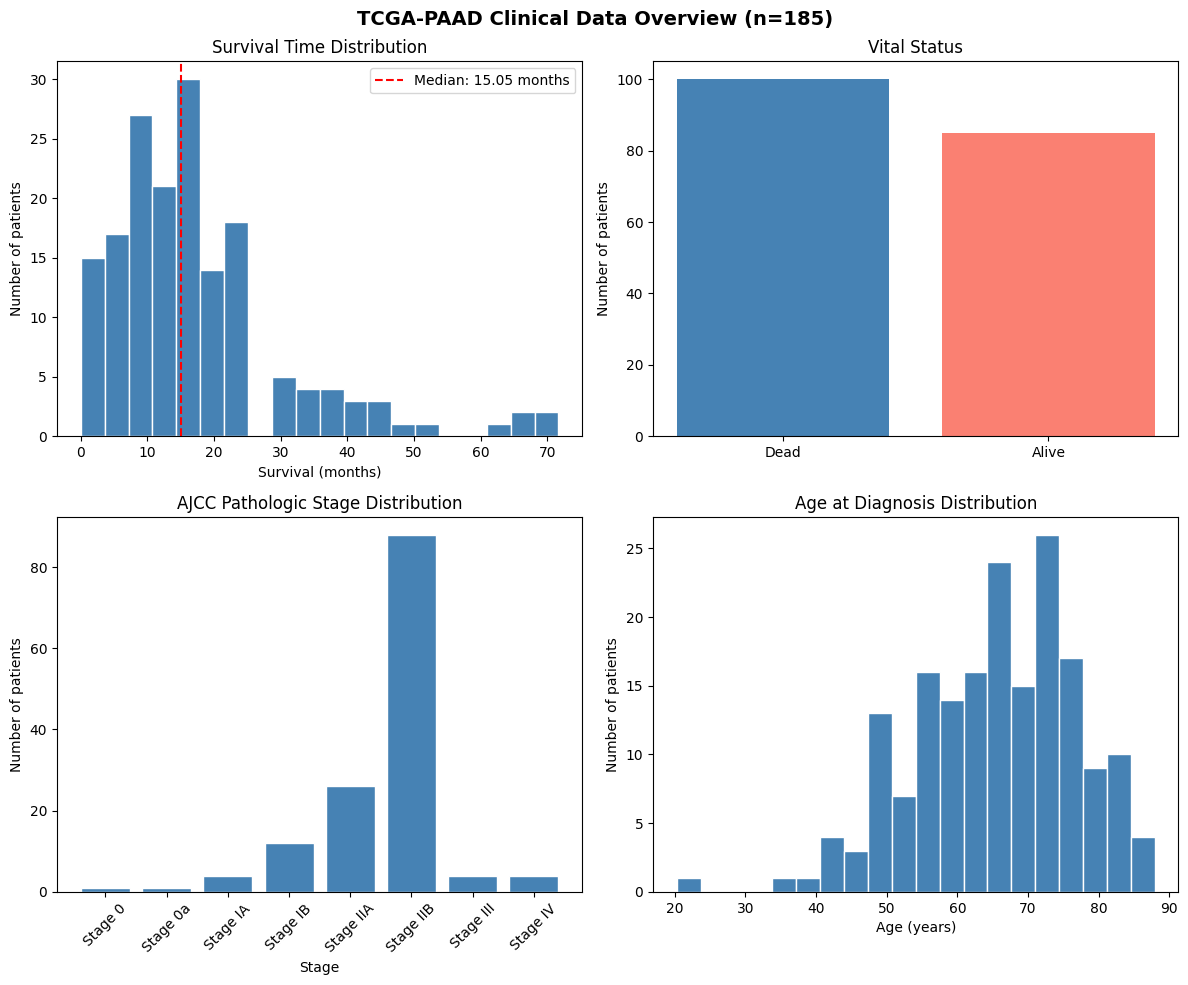

In [11]:
# ── Step 6: EDA Visualizations ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('TCGA-PAAD Clinical Data Overview (n=185)', fontsize=14, fontweight='bold')

# Plot 1: Survival time distribution
axes[0,0].hist(df['survival_months'].dropna(), bins=20, color='steelblue', edgecolor='white')
axes[0,0].set_title('Survival Time Distribution')
axes[0,0].set_xlabel('Survival (months)')
axes[0,0].set_ylabel('Number of patients')
axes[0,0].axvline(df['survival_months'].median(), color='red', linestyle='--', 
                   label=f'Median: {df["survival_months"].median()} months')
axes[0,0].legend()

# Plot 2: Vital status
status_counts = df['demographic.vital_status'].value_counts()
axes[0,1].bar(status_counts.index, status_counts.values, color=['steelblue','salmon'])
axes[0,1].set_title('Vital Status')
axes[0,1].set_ylabel('Number of patients')

# Plot 3: Tumor stage distribution
stage_counts = df['diagnoses.ajcc_pathologic_stage'].value_counts().sort_index()
axes[1,0].bar(stage_counts.index, stage_counts.values, color='steelblue', edgecolor='white')
axes[1,0].set_title('AJCC Pathologic Stage Distribution')
axes[1,0].set_xlabel('Stage')
axes[1,0].set_ylabel('Number of patients')
axes[1,0].tick_params(axis='x', rotation=45)

# Plot 4: Age at diagnosis distribution
df['diagnoses.age_at_diagnosis'] = pd.to_numeric(df['diagnoses.age_at_diagnosis'], errors='coerce')
df['age_at_dx_years'] = (df['diagnoses.age_at_diagnosis'] / 365.25).round(1)
axes[1,1].hist(df['age_at_dx_years'].dropna(), bins=20, color='steelblue', edgecolor='white')
axes[1,1].set_title('Age at Diagnosis Distribution')
axes[1,1].set_xlabel('Age (years)')
axes[1,1].set_ylabel('Number of patients')

plt.tight_layout()
plt.savefig('/Users/simrankrandhawa/local_R_projects/TCGA-PAAD/results/figures/01_clinical_eda.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

In [12]:
import os

# Create the output directory if it doesn't exist
os.makedirs('/Users/simrankrandhawa/local_R_projects/TCGA-PAAD/results/figures/', exist_ok=True)

# Re-save the figure
fig.savefig('/Users/simrankrandhawa/local_R_projects/TCGA-PAAD/results/figures/01_clinical_eda.png',
            dpi=150, bbox_inches='tight')
print("Plot saved successfully.")

Plot saved successfully.


In [13]:
# ── Step 7: Export clean dataset for R ───────────────────────
output_path = '/Users/simrankrandhawa/local_R_projects/TCGA-PAAD/data/tcga_paad_clean.csv'
os.makedirs('/Users/simrankrandhawa/local_R_projects/TCGA-PAAD/data/', exist_ok=True)

df.to_csv(output_path, index=False)
print(f"Clean dataset exported: {df.shape[0]} patients, {df.shape[1]} variables")
print(f"Saved to: {output_path}")

Clean dataset exported: 185 patients, 26 variables
Saved to: /Users/simrankrandhawa/local_R_projects/TCGA-PAAD/data/tcga_paad_clean.csv


/var/folders/bz/90kmc8jj57537qrvcvrsc97r0000gn/T/ipykernel_44998/12351923.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=stage_data, x='stage_simple', y='survival_months',
/var/folders/bz/90kmc8jj57537qrvcvrsc97r0000gn/T/ipykernel_44998/12351923.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='demographic.gender', y='survival_months',


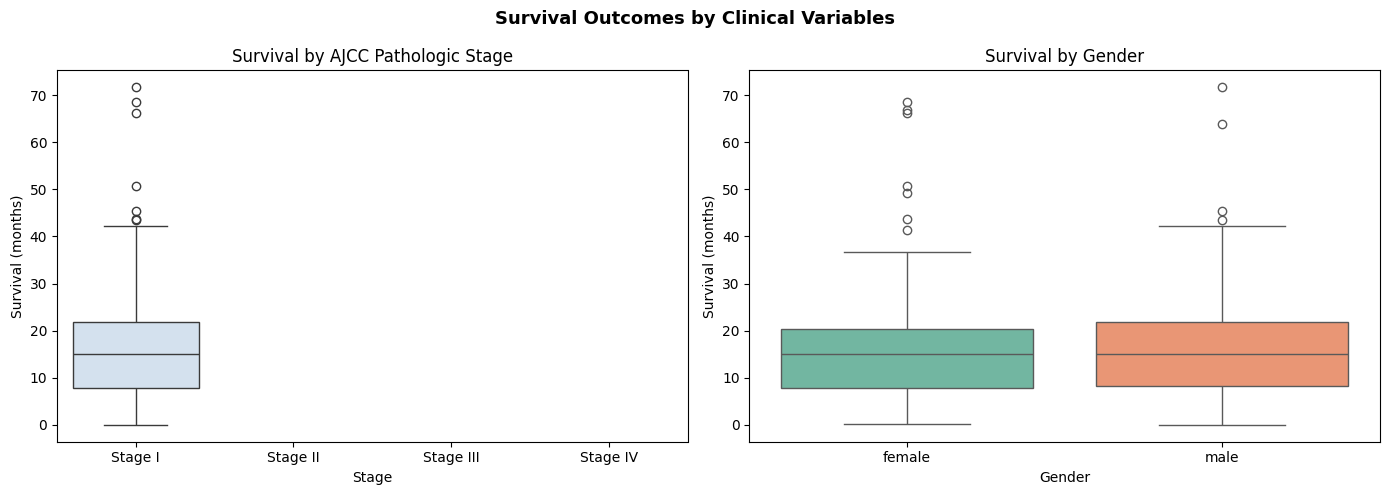

Plot saved.


In [14]:
# ── Bonus: Survival by Stage (boxplot) ───────────────────────
# Clean stage column — simplify to broad categories
df['stage_simple'] = df['diagnoses.ajcc_pathologic_stage'].str.extract(
    r'(Stage I|Stage II|Stage III|Stage IV)')

stage_order = ['Stage I', 'Stage II', 'Stage III', 'Stage IV']
stage_data = df[df['stage_simple'].isin(stage_order)].copy()

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Survival Outcomes by Clinical Variables', fontsize=13, fontweight='bold')

# Plot 1: Survival by stage (seaborn boxplot)
sns.boxplot(data=stage_data, x='stage_simple', y='survival_months',
            order=stage_order, palette='Blues', ax=axes2[0])
axes2[0].set_title('Survival by AJCC Pathologic Stage')
axes2[0].set_xlabel('Stage')
axes2[0].set_ylabel('Survival (months)')

# Plot 2: Survival by gender (seaborn boxplot)
sns.boxplot(data=df, x='demographic.gender', y='survival_months',
            palette='Set2', ax=axes2[1])
axes2[1].set_title('Survival by Gender')
axes2[1].set_xlabel('Gender')
axes2[1].set_ylabel('Survival (months)')

plt.tight_layout()
plt.savefig('/Users/simrankrandhawa/local_R_projects/TCGA-PAAD/results/figures/02_survival_by_clinical_vars.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")